# 데이터셋 확인

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_good = []
for i in range(1, 5):
  data = np.load(f"/content/dataset_good_{i}.npz")
  data_good.append(data)

In [26]:
data_good

[NpzFile '/content/dataset_good_1.npz' with keys: sequences, labels,
 NpzFile '/content/dataset_good_2.npz' with keys: sequences, labels,
 NpzFile '/content/dataset_good_3.npz' with keys: sequences, labels,
 NpzFile '/content/dataset_good_4.npz' with keys: sequences, labels]

In [18]:
data_bad = np.load("/content/dataset_bad_1.npz")
data_bad

NpzFile '/content/dataset_bad_1.npz' with keys: sequences, labels

In [30]:
num_features = 6; # feature의 개수 6개로 고정



1.   왼손목 - 왼어깨 거리
2.   양쪽 팔꿈치 거리
3.   왼손목 속도
4.   왼팔 각도
5.   오른팔 각도
6.   오른손목 각도



# 🌱 Feature 기준 통계

## good 데이터셋에 대한 분석


### good 데이터셋 하나에 대한 분석

In [20]:
seq_good_1 = data_good[0]['sequences']
seq_good_1.shape

(548, 30, 6)



*   **\# of sample**: 548
*   **length of sequence, time step**: 30
*   **\# of feature**: 6

**feature 기준 통계**를 내기 위해서, axis(0,1)로 줄이기
*axis=0 → 샘플 방향 제거 / axis=1 → 시간 방향 제거*


#### 데이터 분포 분석

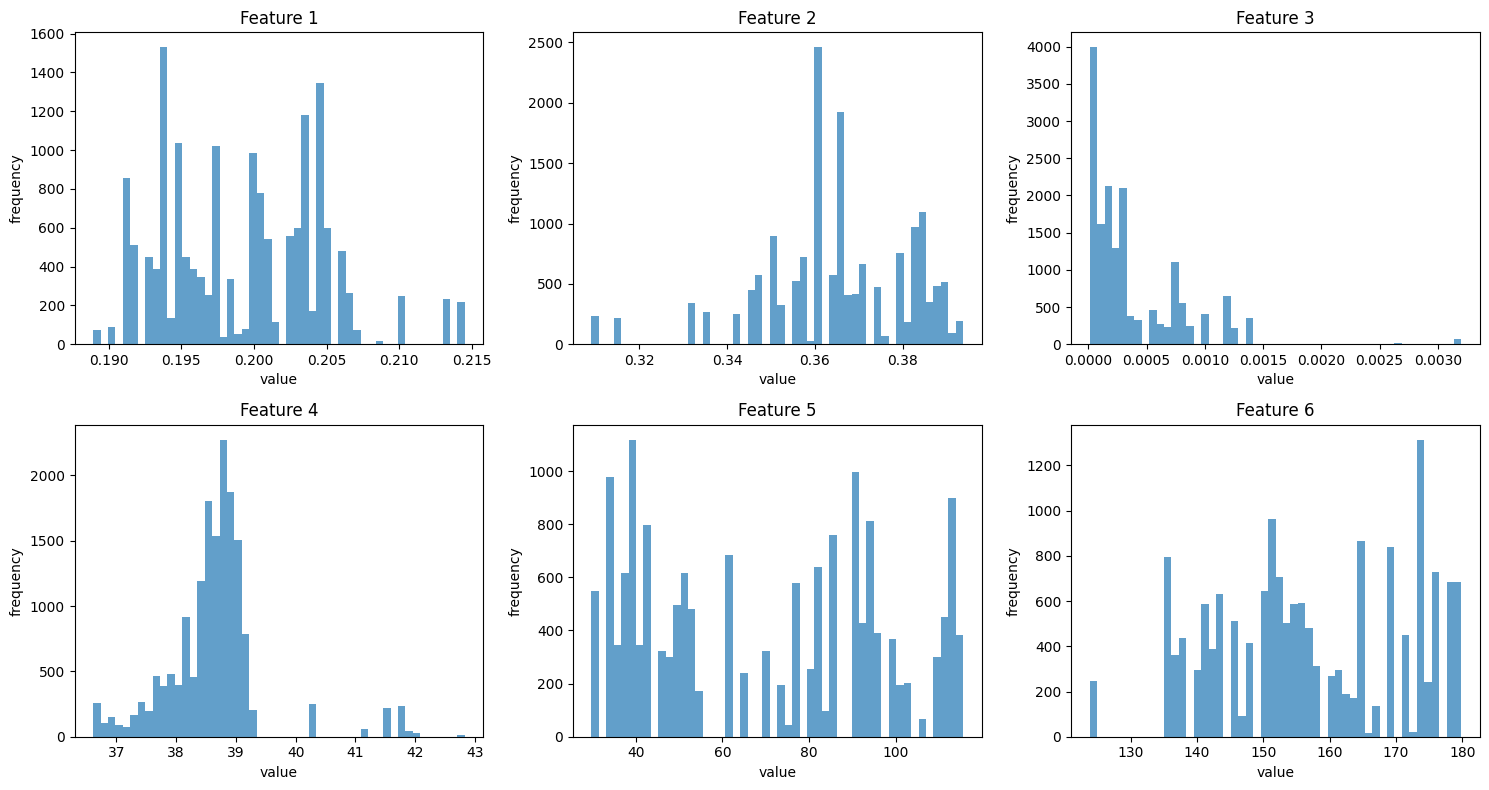

In [34]:
# 일단 dataset_good_1.npz에 대해서만 분석
plt.figure(figsize=(15,8))

for i in range(num_features):
  plt.subplot(2, 3, i+1)

  feature_values_good = seq_good_1[:, :, i].flatten() # (548 * 30, )

  plt.hist(feature_values_good, bins=50, alpha=0.7)
  plt.title(f'Feature {i+1}')
  plt.xlabel('value')
  plt.ylabel('frequency')

plt.tight_layout()
plt.show()

위 히스토그램은 각 feature별로 나오는 값들의 빈도를 나타내는 차트이다. 시간과 관계 없는 전체 분포이다. 이상치나 스케일 차이를 보여준다.

*추가로, `flatten()`은 히스토그램을 그리기 위해 2차원 데이터를 1차원으로 펴는 역할을 한다. 샘플별 데이터를 그냥 다 합쳐서 하나의 큰 데이터 집합을 생성한다.

#### Boxplot 분석

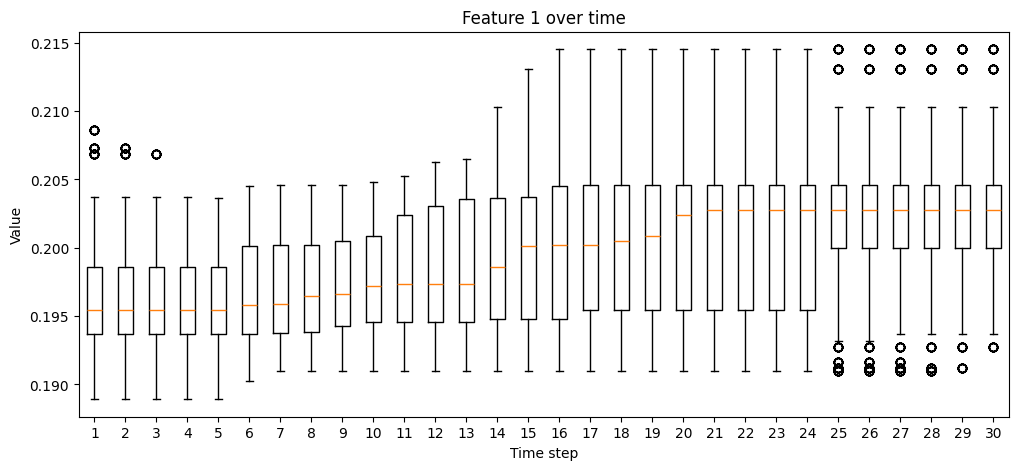

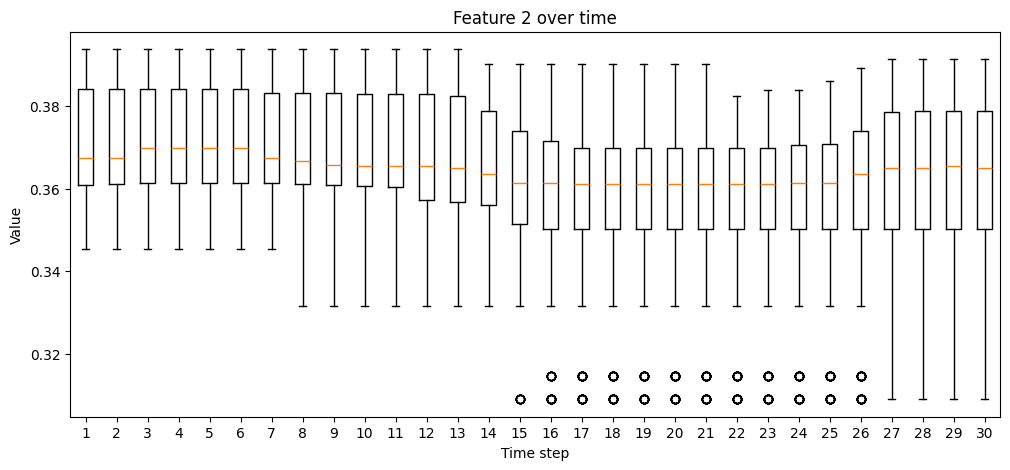

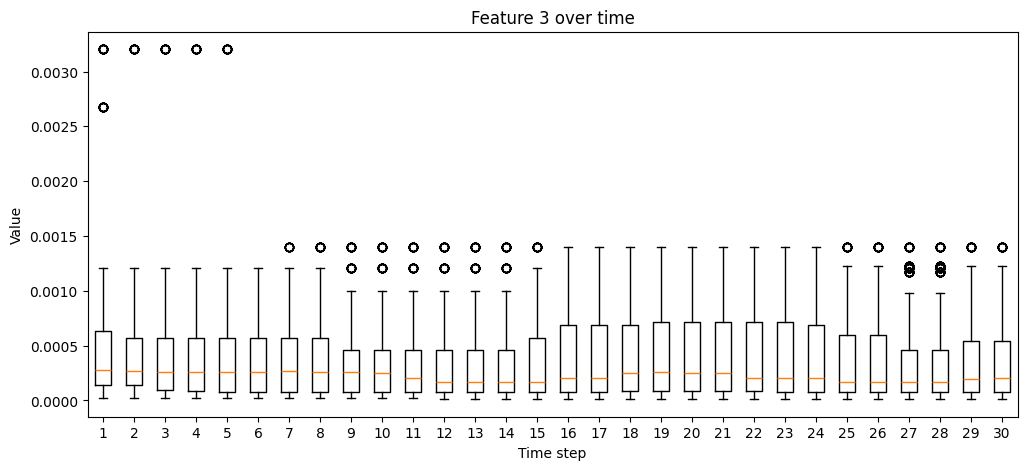

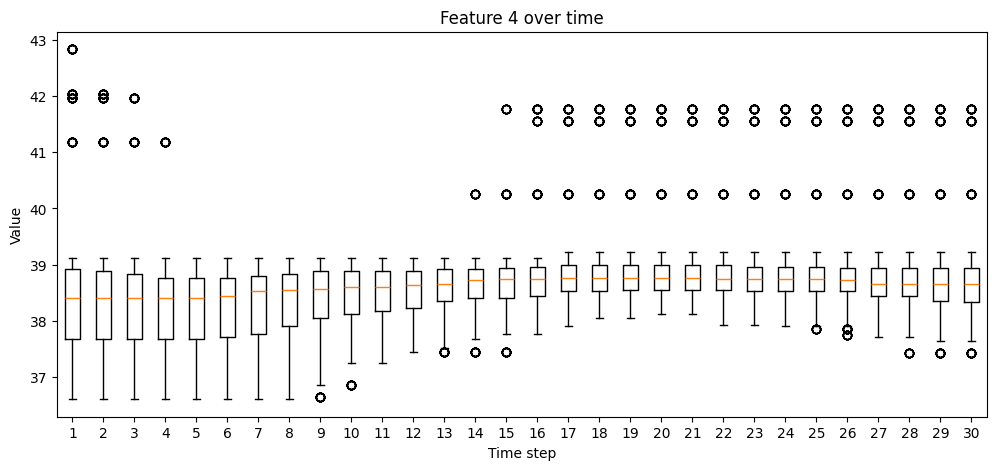

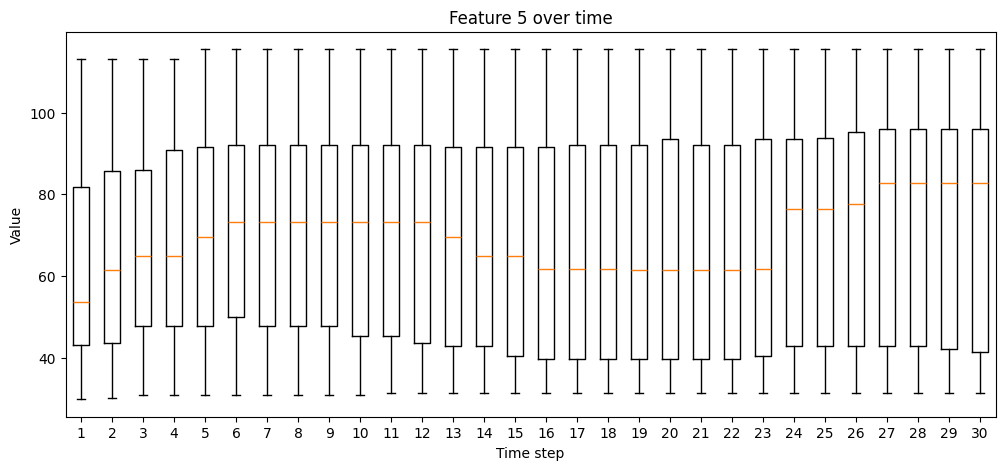

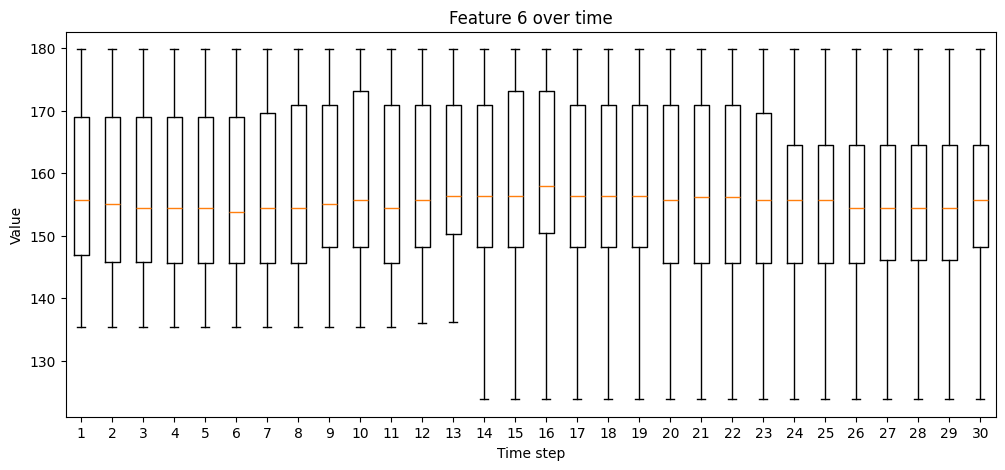

In [23]:
# 시간별
num_timesteps_good1 = seq_good_1.shape[1]

for i in range(num_features):
    plt.figure(figsize=(12, 5))

    data = [seq_good_1[:, t, i] for t in range(num_timesteps_good1)]

    plt.boxplot(data)
    plt.title(f'Feature {i+1} over time')
    plt.xlabel('Time step')
    plt.ylabel('Value')

    plt.show()

#### 최솟값, 최댓값, 평균값 수치 확인

In [24]:
feature_min = np.min(seq_good_1, axis=(0,1))
feature_max = np.max(seq_good_1, axis=(0,1))
feature_mean = np.mean(seq_good_1, axis=(0,1))

In [25]:
for i in range(seq_good_1.shape[2]):
    print(f"Feature {i+1}")
    print(f"  min:  {feature_min[i]}")
    print(f"  max:  {feature_max[i]}")
    print(f"  mean: {feature_mean[i]}")

Feature 1
  min:  0.18892152607440948
  max:  0.21453066170215607
  mean: 0.1992742121219635
Feature 2
  min:  0.3090560734272003
  max:  0.3937516510486603
  mean: 0.3648231625556946
Feature 3
  min:  1.101674570236355e-05
  max:  0.003203227184712887
  mean: 0.00038021872751414776
Feature 4
  min:  36.61104965209961
  max:  42.82986068725586
  mean: 38.63142395019531
Feature 5
  min:  29.796010971069336
  max:  115.50090026855469
  mean: 69.52731323242188
Feature 6
  min:  123.82764434814453
  max:  179.84353637695312
  mean: 157.13941955566406


### good 데이터셋 전체에 대한 분석

**각 데이터셋별 분포**를 확인한다.

feature별로 색깔을 다르게 해서 각 데이터셋별로 feature의 분포가 어떻게 되어있는지 시각화해서 분석한다.

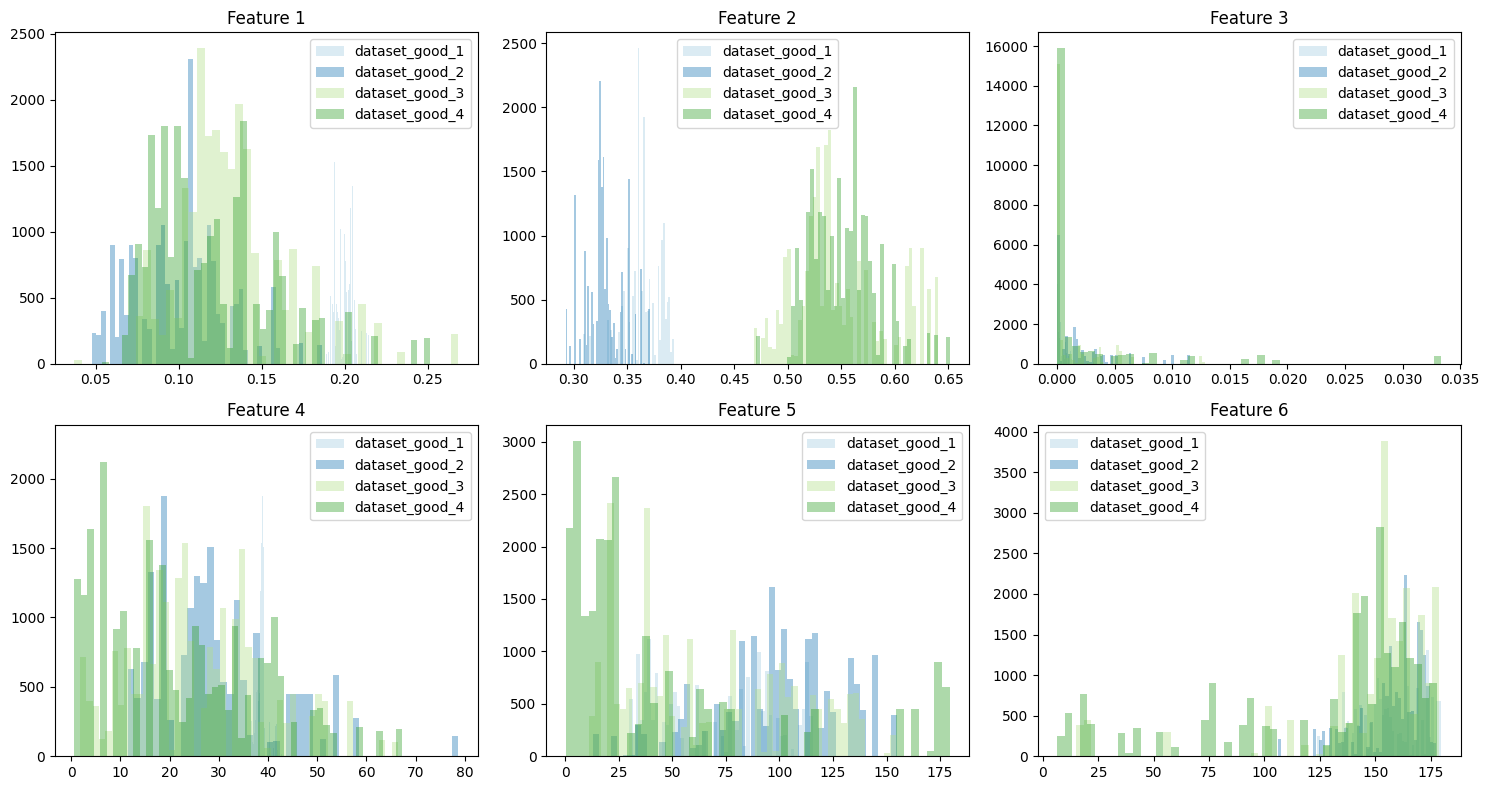

In [51]:
# colors = ['blue', 'red', 'green', 'orange']
colors = ['#a6cee3', '#1f78b4', '#b2df8a', '#33a02c']

plt.figure(figsize=(15, 8))

for f in range(num_features):
  plt.subplot(2, 3, f+1)

  for i in range(4): # dataset 4개
    seq = data_good[i]['sequences']
    values = seq[:, :, f].flatten()

    plt.hist(values, bins=50, alpha=0.4, color=colors[i], label=f'dataset_good_{i+1}')
  plt.title(f'Feature {f+1}')
  plt.legend()

plt.tight_layout()
plt.show()

#### 모든 good 데이터를 합쳐서 분포 분석

In [40]:
# 4개의 data_good을 하나로 concat
all_seq = np.concatenate(
    [data_good[i]['sequences'] for i in range(4)],
    axis=0
)

all_seq.shape #(548*4, 30, 6)

(2743, 30, 6)

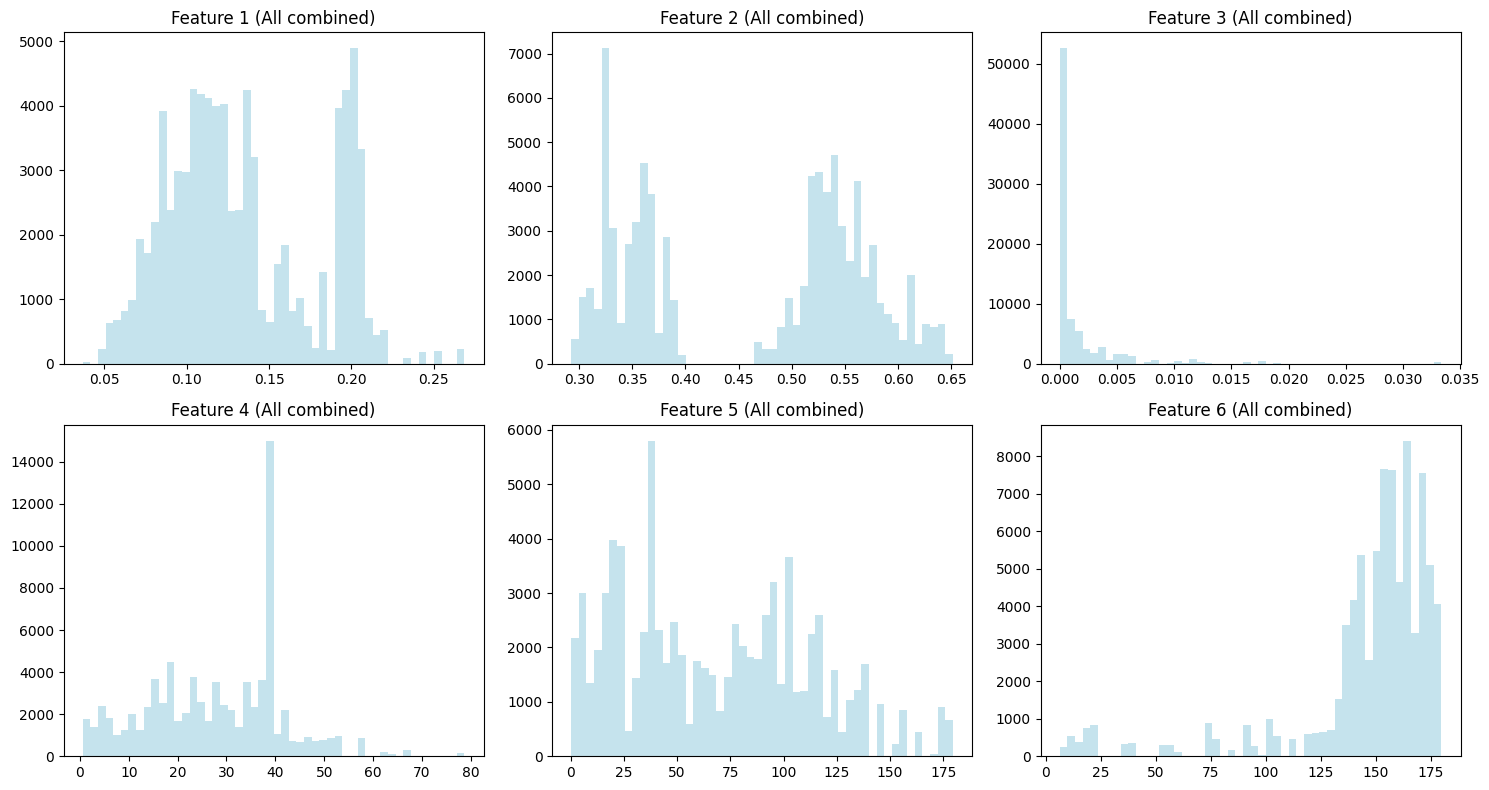

In [50]:
plt.figure(figsize=(15, 8))

for f in range(num_features):
    plt.subplot(2, 3, f+1)

    values = all_seq[:, :, f].flatten()

    plt.hist(values, bins=50, alpha=0.7, color='lightblue')
    plt.title(f'Feature {f+1} (All combined)')

plt.tight_layout()
plt.show()

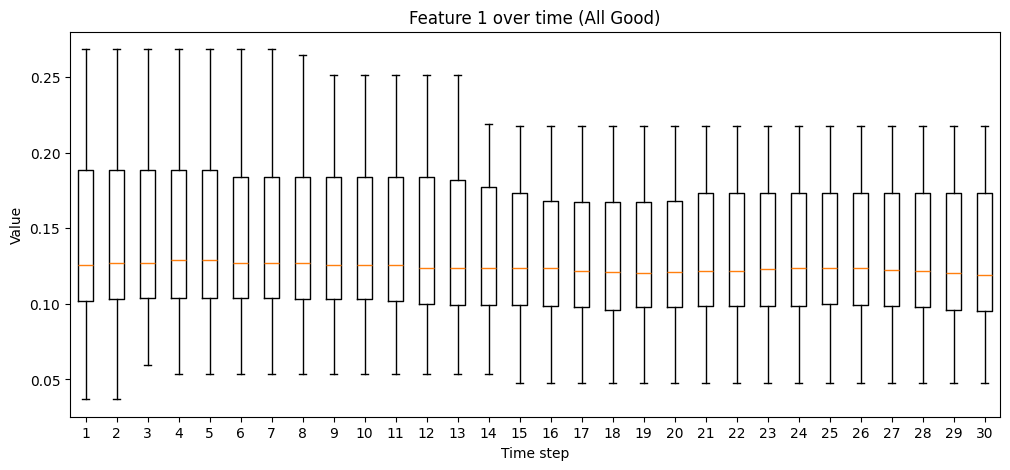

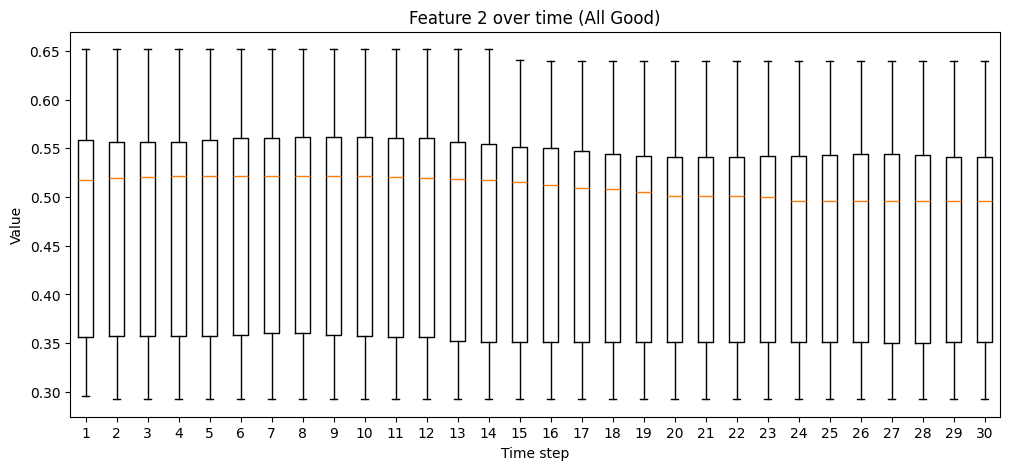

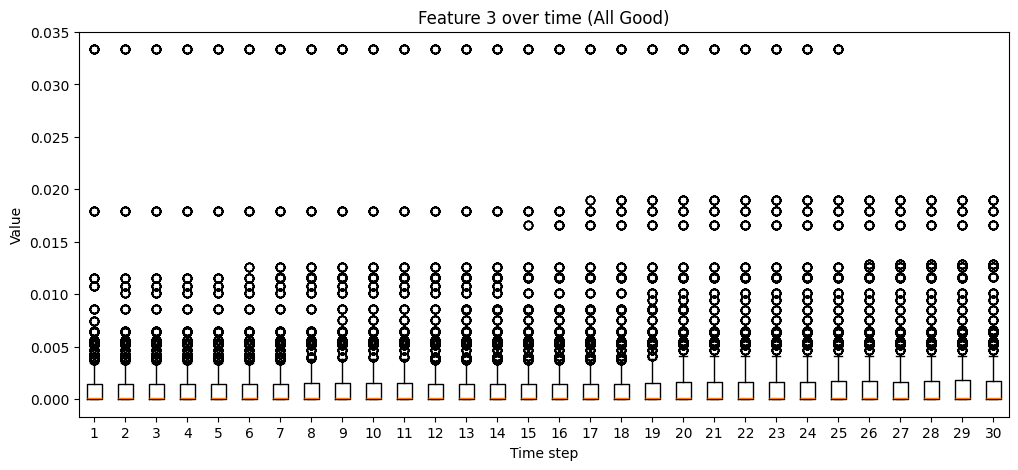

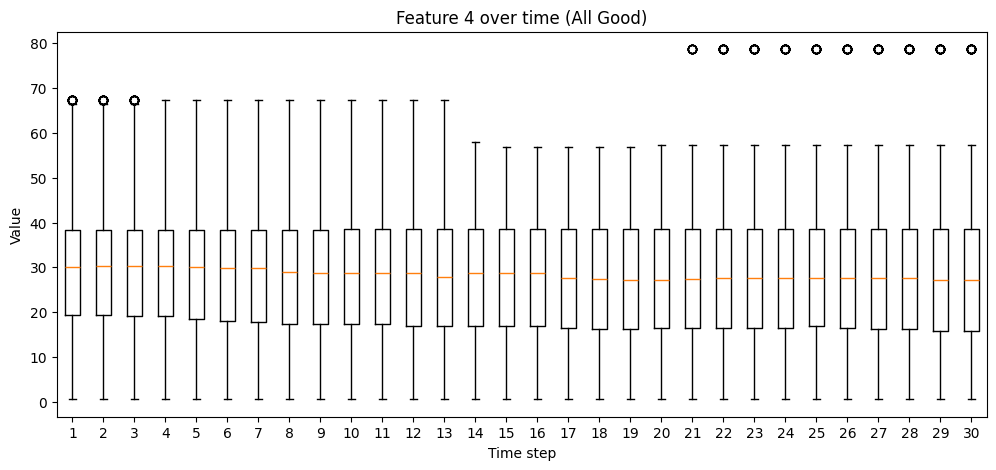

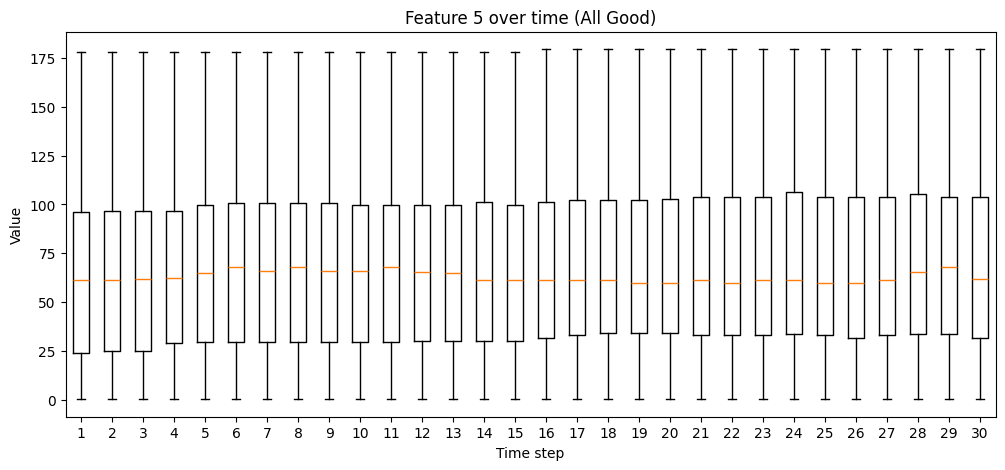

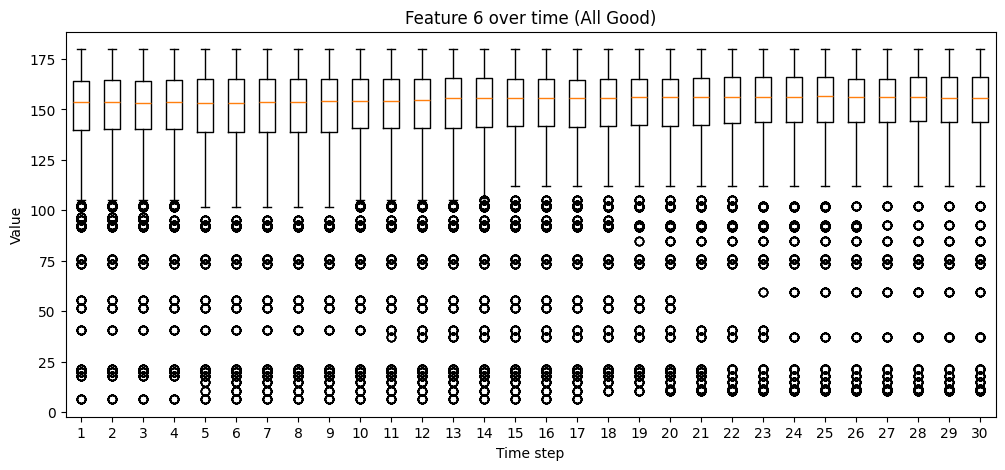

In [46]:
# feature별 + 시간별 boxplot
for f in range(all_seq.shape[2]):
    plt.figure(figsize=(12, 5))

    data = [all_seq[:, t, f] for t in range(all_seq.shape[1])]

    plt.boxplot(data)
    plt.title(f'Feature {f+1} over time (All Good)')
    plt.xlabel('Time step')
    plt.ylabel('Value')

    plt.show()

In [100]:
all_seq_means = []
all_seq_medians = []
min_no_outlier = []
max_no_outlier = []

for f in range(num_features):
  values = all_seq[:, :, f].flatten()

  # 평균값
  mean_val = np.mean(values)
  all_seq_means.append(mean_val)

  # 중앙값
  median_val = np.median(values)
  all_seq_medians.append(median_val)

  # IQR 계산
  Q1 = np.percentile(values, 25)
  Q3 = np.percentile(values, 75)
  IQR = Q3 - Q1

  # 이상치 범위 설정
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  # 이상치 제거한 데이터
  filtered = values[(values >= lower_bound) & (values <= upper_bound)]

  # 최솟값, 최댓값 저장
  min_no_outlier.append(filtered.min())
  max_no_outlier.append(filtered.max())

# 출력
for i in range(num_features):
  print(f"Feature {i+1}:")
  print(f"  Mean: {all_seq_means[i]:.4f}")
  print(f"  Median: {all_seq_medians[i]:.4f}")  # 추가
  print(f"  Min (no outlier): {min_no_outlier[i]:.4f}")
  print(f"  Max (no outlier): {max_no_outlier[i]:.4f}")
  print()


Feature 1:
  Mean: 0.1345
  Median: 0.1237
  Min (no outlier): 0.0369
  Max (no outlier): 0.2686

Feature 2:
  Mean: 0.4621
  Median: 0.5109
  Min (no outlier): 0.2925
  Max (no outlier): 0.6517

Feature 3:
  Mean: 0.0016
  Median: 0.0001
  Min (no outlier): 0.0000
  Max (no outlier): 0.0039

Feature 4:
  Mean: 27.8065
  Median: 28.6317
  Min (no outlier): 0.5702
  Max (no outlier): 67.2723

Feature 5:
  Mean: 67.9785
  Median: 61.5950
  Min (no outlier): 0.2269
  Max (no outlier): 179.5376

Feature 6:
  Mean: 146.3670
  Median: 155.2821
  Min (no outlier): 112.1787
  Max (no outlier): 179.8435



#### **KDE** 버전



KDE = Kerenel Density Estimation

히스토그램을 부드러운 곡선으로 만든 것.



*   장점: 적은 노이즈, 패턴 잘 보임, 여러 dataset이 겹쳐도 비교하기 수월.
*   사용하면 안 될 때:
    * 데이터 개수가 너무 적을 때
    * 정확한 개수 비교가 필요할 때

**나의 데이터셋은 개수가 적기 때문에 kDE 버전은 고려하지 않겠다. 참고만 하면 좋을듯.**

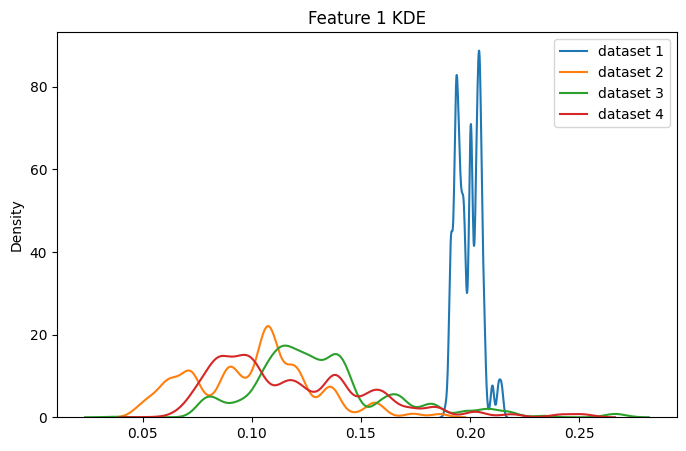

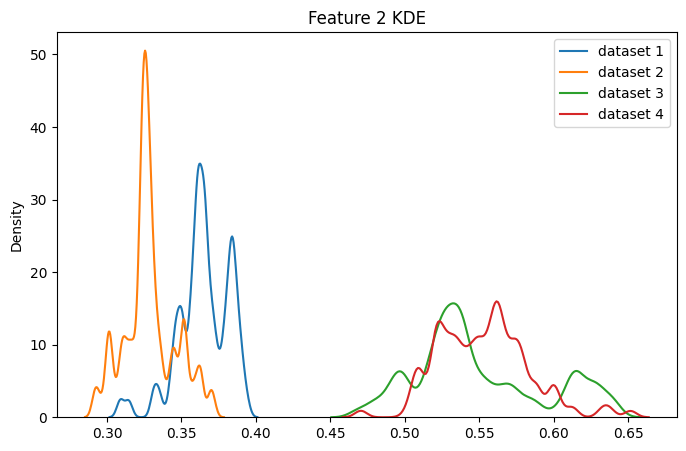

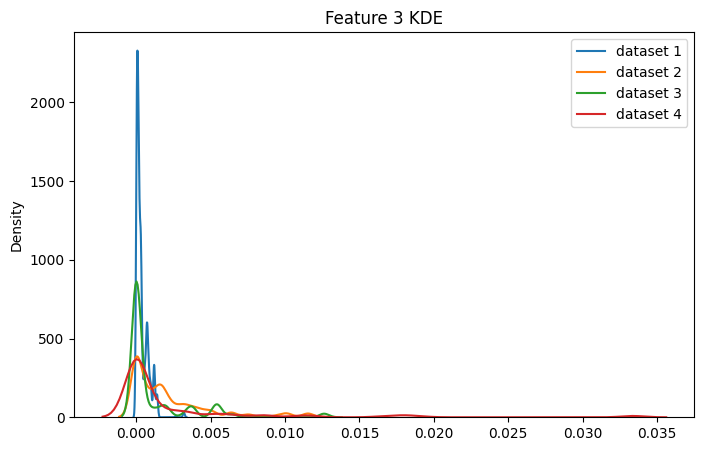

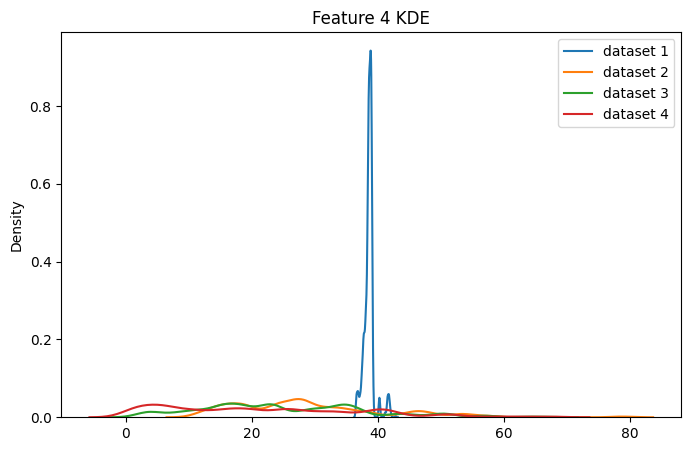

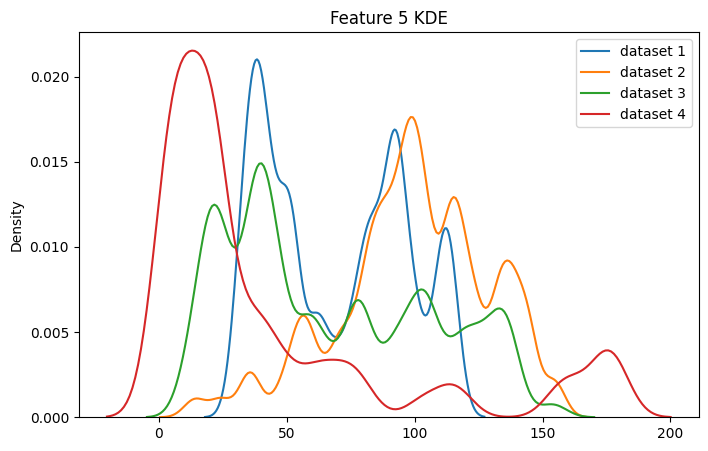

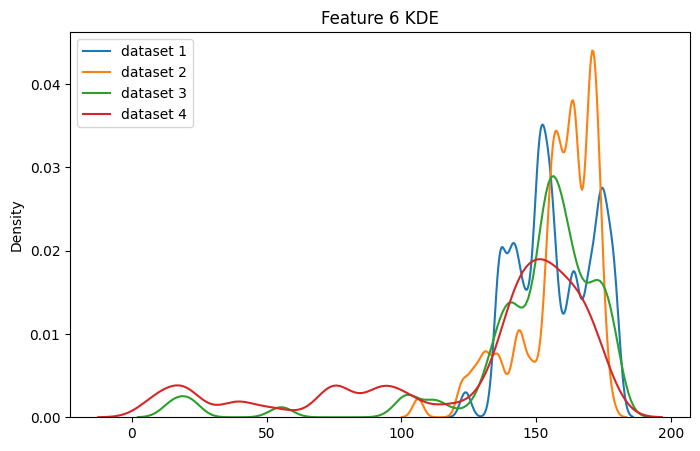

In [44]:
for f in range(num_features):
    plt.figure(figsize=(8, 5))

    for i in range(4):
        seq = data_good[i]['sequences']
        values = seq[:, :, f].flatten()

        sns.kdeplot(values, label=f'dataset {i+1}')

    plt.title(f'Feature {f+1} KDE')
    plt.legend()
    plt.show()

## bad 데이터셋에 대한 분석

`dataset_bad_1.npz` 파일이 하나인 관계로 일달 bad dataset은 하나만 분석하는 것으로 한다.

In [29]:
seq_bad = data_bad['sequences']
seq_bad.shape

(371, 30, 6)

#### 데이터 분포 분석

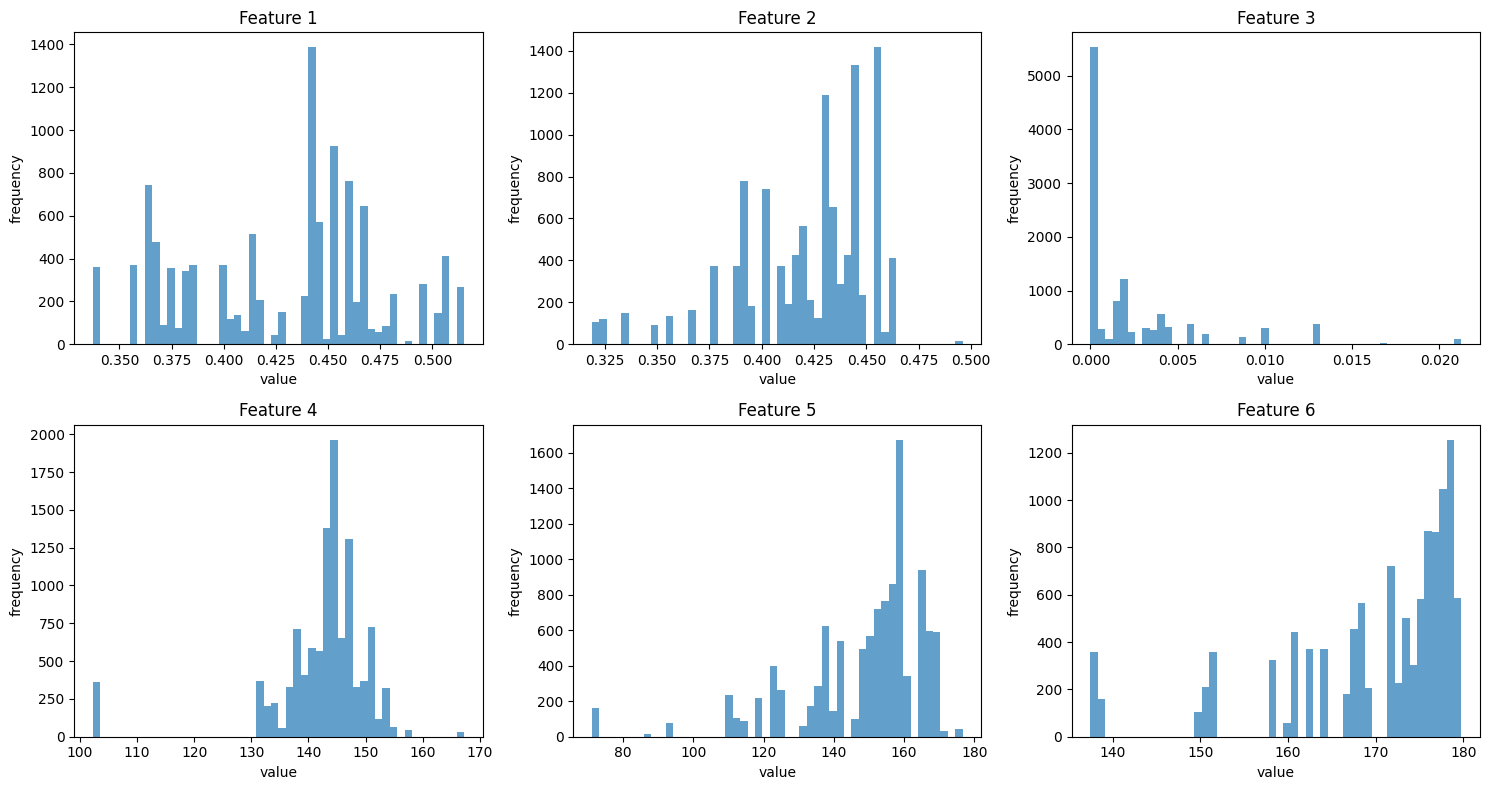

In [33]:
plt.figure(figsize=(15,8))

for i in range(num_features):
  plt.subplot(2, 3, i+1)

  feature_values_bad = seq_bad[:, :, i].flatten() # (548 * 30, )

  plt.hist(feature_values_bad, bins=50, alpha=0.7)
  plt.title(f'Feature {i+1}')
  plt.xlabel('value')
  plt.ylabel('frequency')

plt.tight_layout()
plt.show()

#### Boxplot 분석

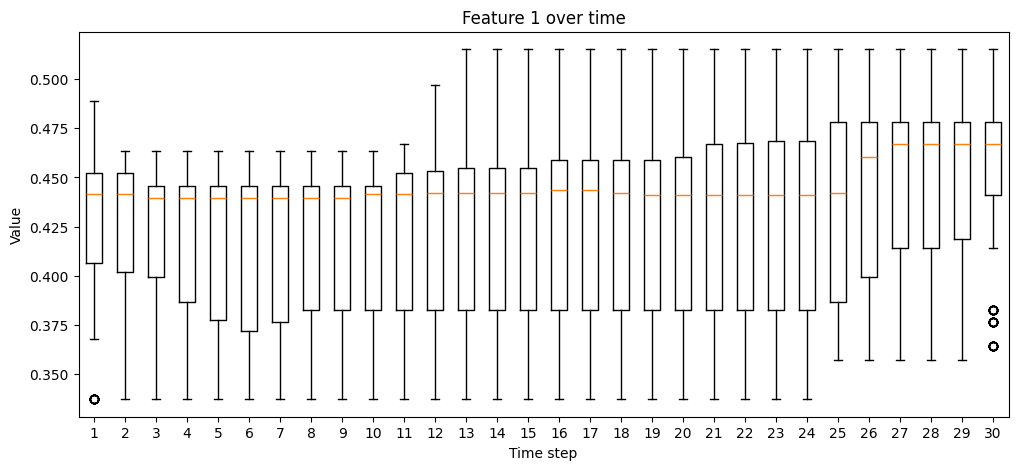

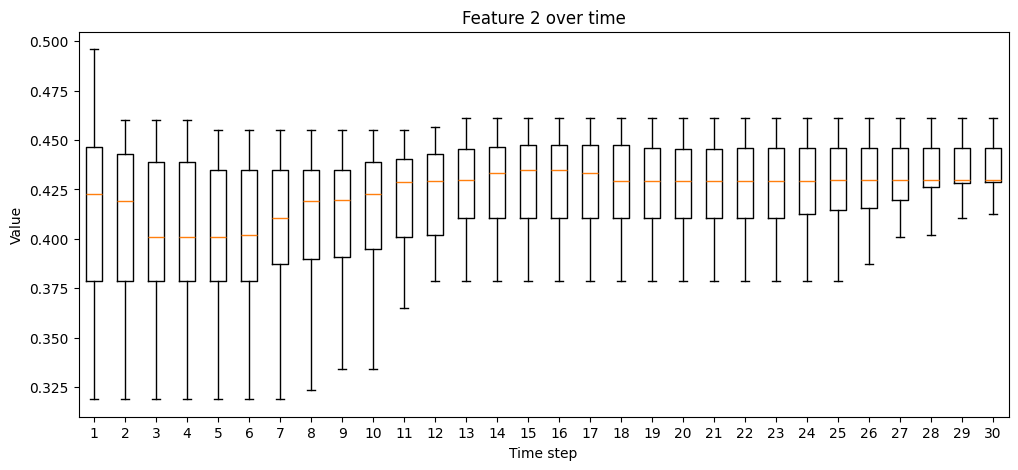

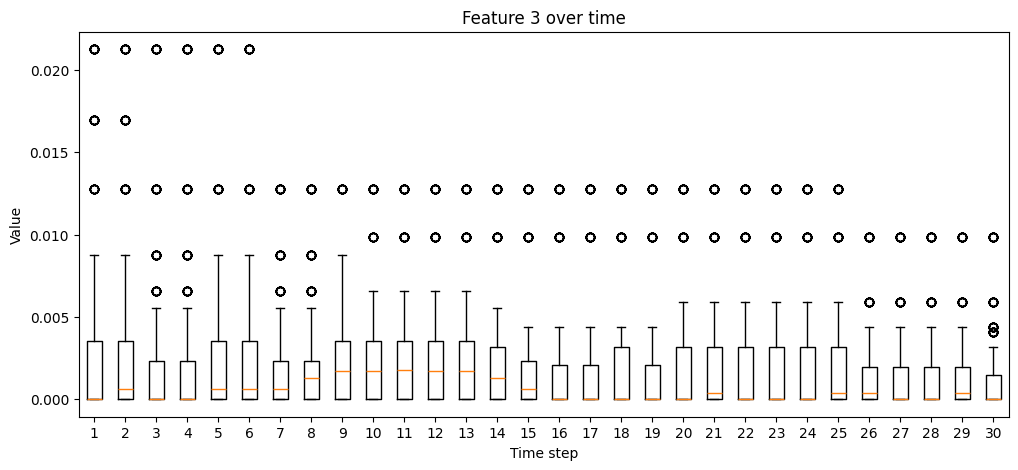

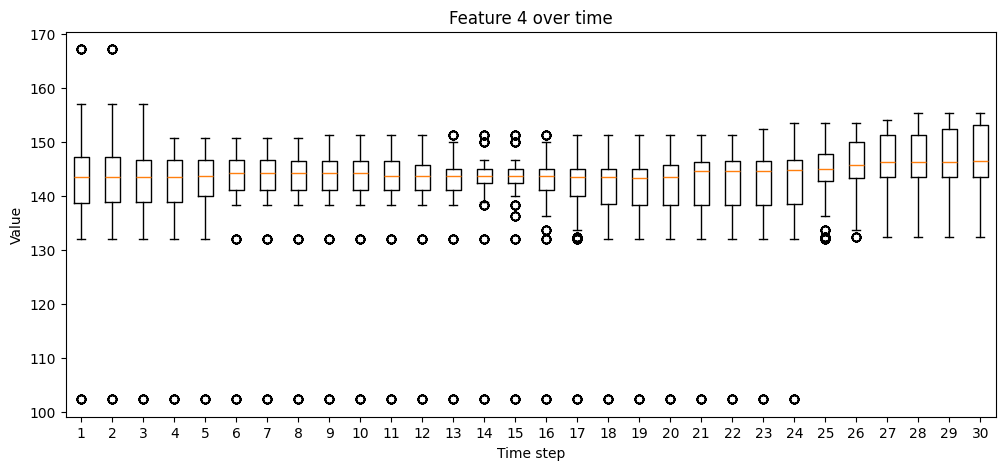

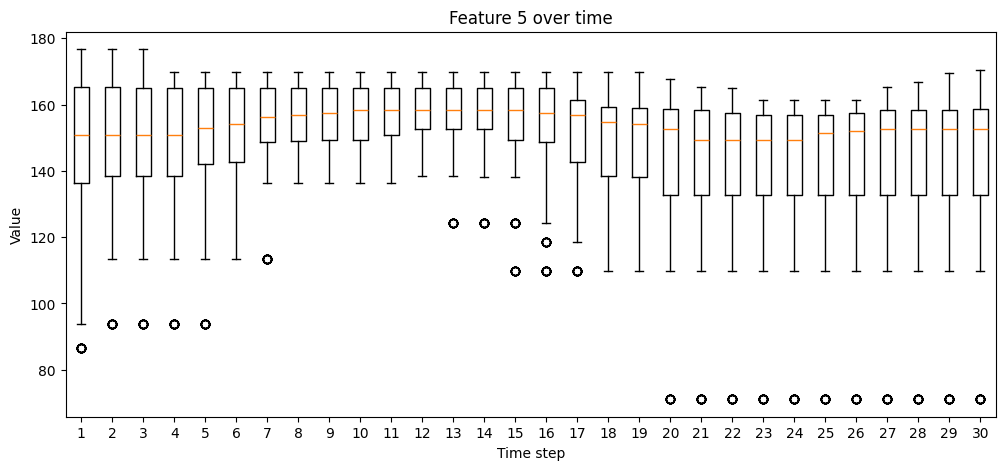

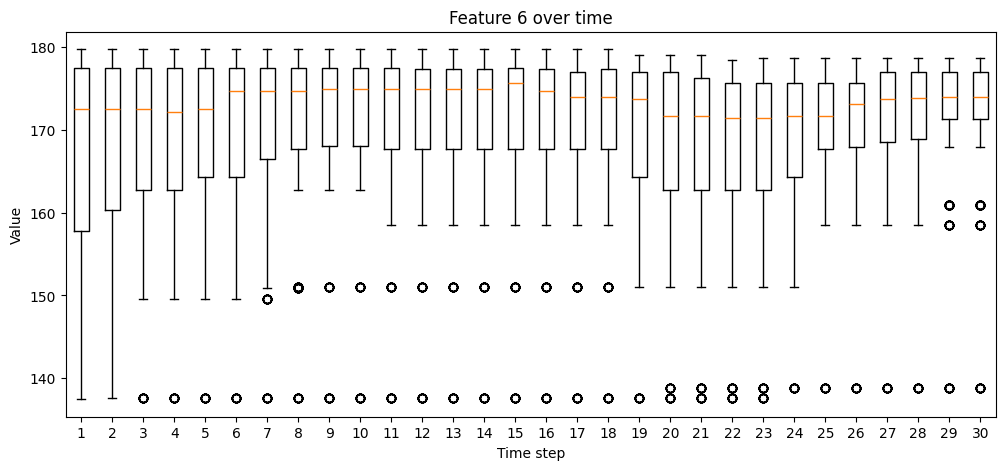

In [35]:
# 시간별
num_timesteps_bad = seq_bad.shape[1]

for i in range(num_features):
    plt.figure(figsize=(12, 5))

    data = [seq_bad[:, t, i] for t in range(num_timesteps_bad)]

    plt.boxplot(data)
    plt.title(f'Feature {i+1} over time')
    plt.xlabel('Time step')
    plt.ylabel('Value')

    plt.show()

## good과 bad 데이터셋 비교 분석



*   `all_seq`: data_good 데이터 합친 것
*   `seq_bad`: data_bad 데이터



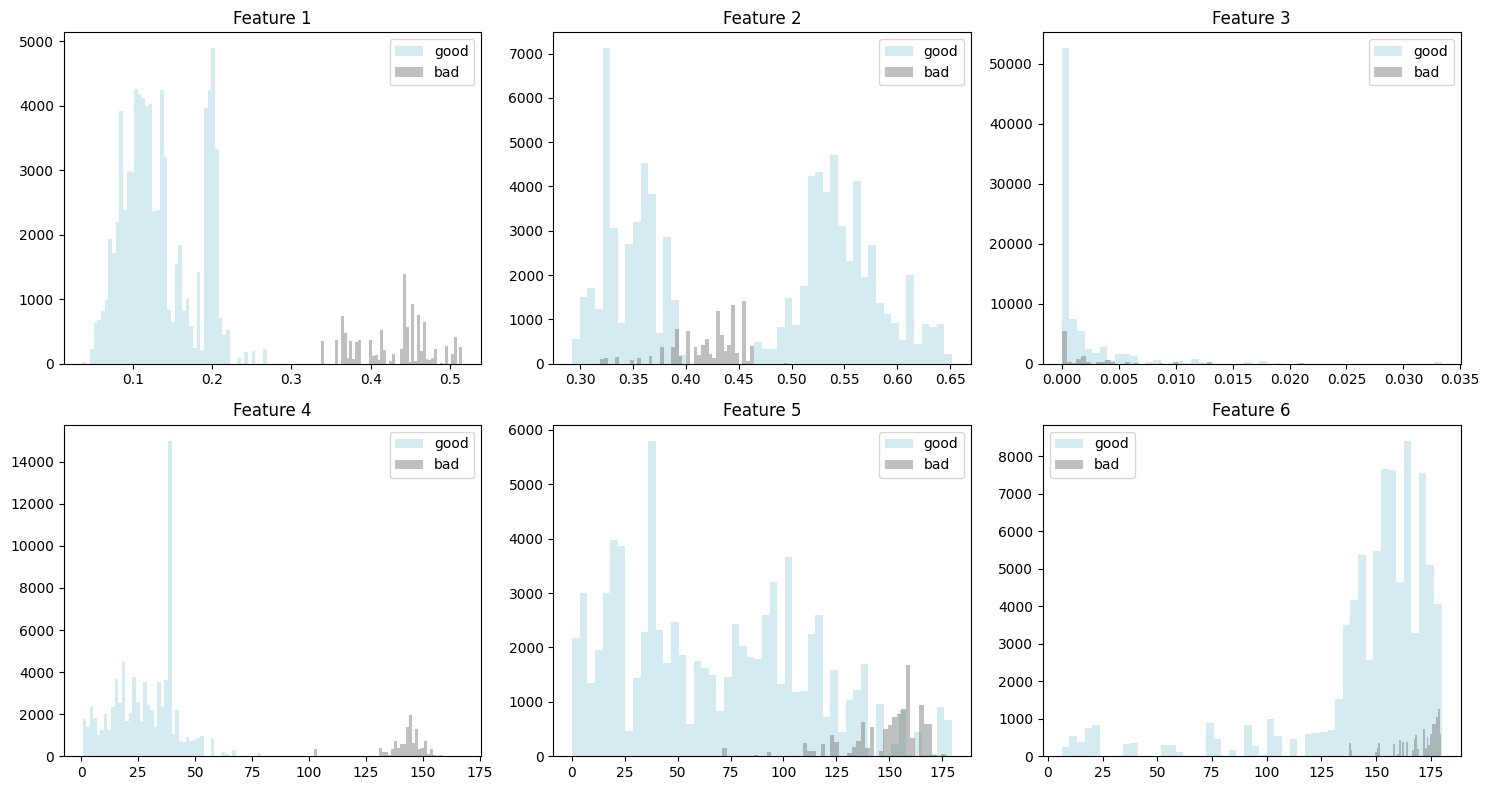

In [54]:
# feature별 전체 분포 비교

plt.figure(figsize=(15, 8))

for f in range(num_features):
    plt.subplot(2, 3, f+1)

    good_value = all_seq[:, :, f].flatten()
    bad_value = seq_bad[:, :, f].flatten()

    plt.hist(good_value, bins=50, alpha=0.5, label='good', color='lightblue')
    plt.hist(bad_value, bins=50, alpha=0.5, label='bad', color='grey')

    plt.title(f'Feature {f+1}')
    plt.legend()

plt.tight_layout()
plt.show()

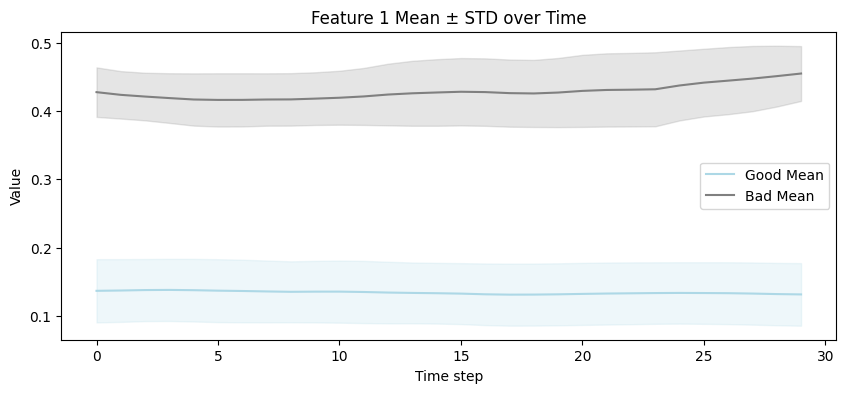

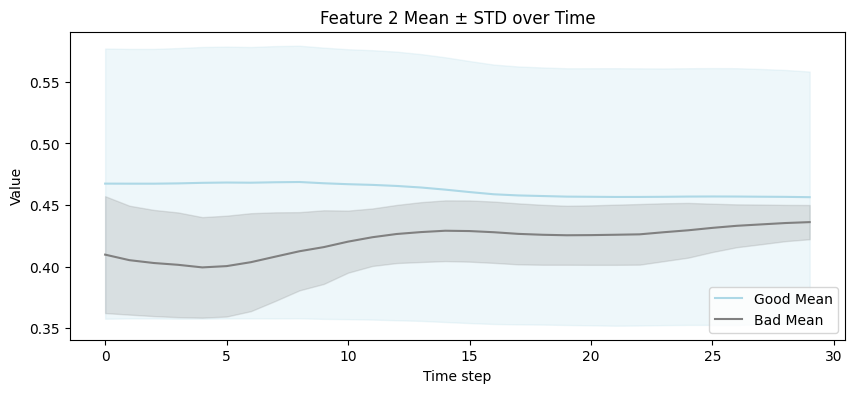

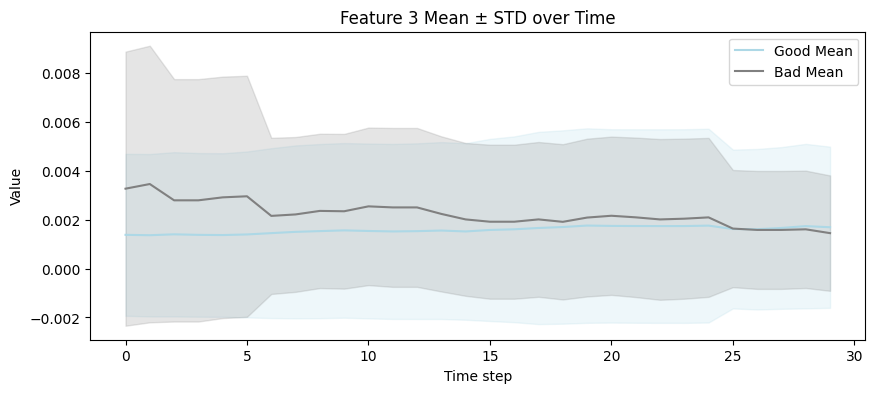

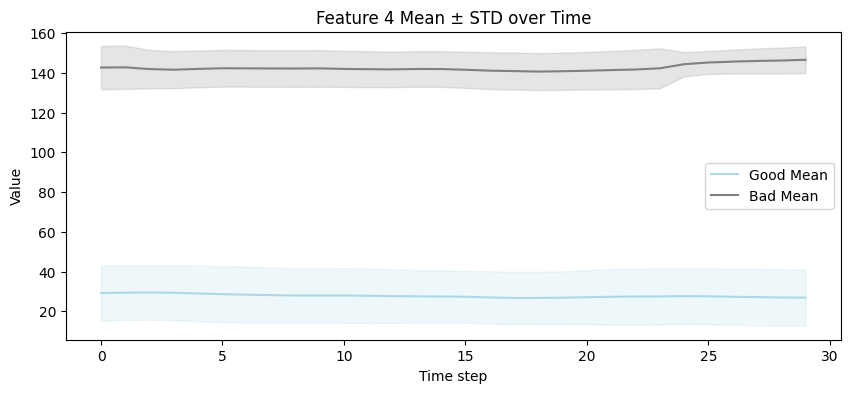

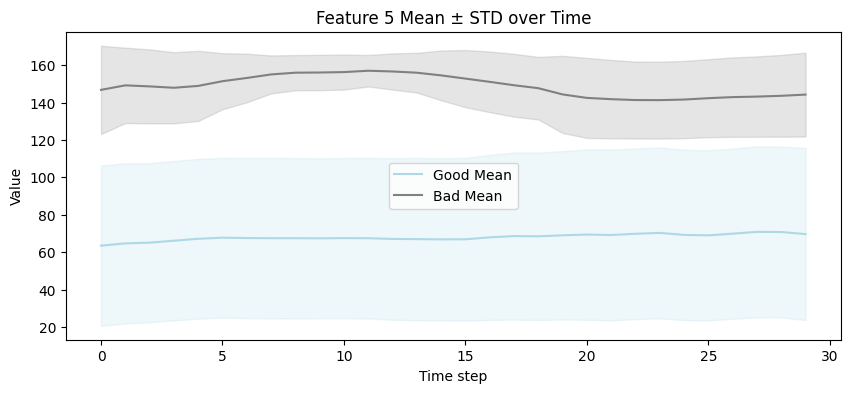

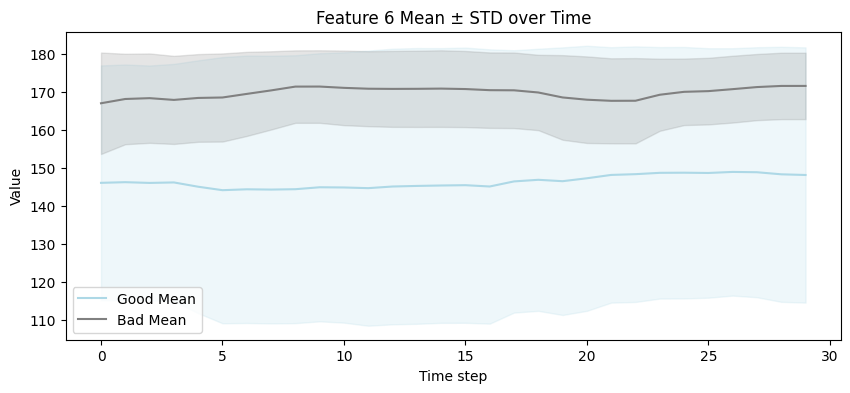

In [58]:
# 시계열 패턴 비교: 시간별 평균 & 분산(표준편차) 시각화

for f in range(num_features):
    plt.figure(figsize=(10,4))

    # 시간별 평균
    good_mean = all_seq[:, :, f].mean(axis=0)
    bad_mean = seq_bad[:, :, f].mean(axis=0)

    # 시간별 표준편차
    good_std = all_seq[:, :, f].std(axis=0)
    bad_std = seq_bad[:, :, f].std(axis=0)

    plt.plot(good_mean, label='Good Mean', color='lightblue')
    plt.fill_between(range(len(good_mean)), good_mean - good_std, good_mean + good_std, color='lightblue', alpha=0.2)

    plt.plot(bad_mean, label='Bad Mean', color='grey')
    plt.fill_between(range(len(bad_mean)), bad_mean - bad_std, bad_mean + bad_std, color='grey', alpha=0.2)

    plt.title(f'Feature {f+1} Mean ± STD over Time')
    plt.xlabel('Time step')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

In [68]:
# scatterplot으로 구간/상황별 분석

def draw_scatterplot_features(start_t=0, end_t=30, feat_x=1, feat_y=6):

  # 분석할 시간 구간 선택 (예: 10~20)
  # 분석할 feature 2개 선택: feature 3과 6

  plt.figure(figsize=(8,6))

  # good 데이터: 시간 구간 평균값으로 scatterplot
  good_x = all_seq[:, start_t:end_t, feat_x-1].mean(axis=1)
  good_y = all_seq[:, start_t:end_t, feat_y-1].mean(axis=1)
  plt.scatter(good_x, good_y, color='lightblue', alpha=0.5, label='Good')

  # bad 데이터: 시간 구간 평균값으로 scatterplot
  bad_x = seq_bad[:, start_t:end_t, feat_x-1].mean(axis=1)
  bad_y = seq_bad[:, start_t:end_t, feat_y-1].mean(axis=1)
  plt.scatter(bad_x, bad_y, color='grey', alpha=0.5, label='Bad')

  plt.xlabel(f'Feature {feat_x} (mean from t={start_t} to {end_t})')
  plt.ylabel(f'Feature {feat_y} (mean from t={start_t} to {end_t})')
  plt.title(f'Scatterplot of Feature {feat_x} vs Feature {feat_y}')
  plt.legend()
  plt.show()

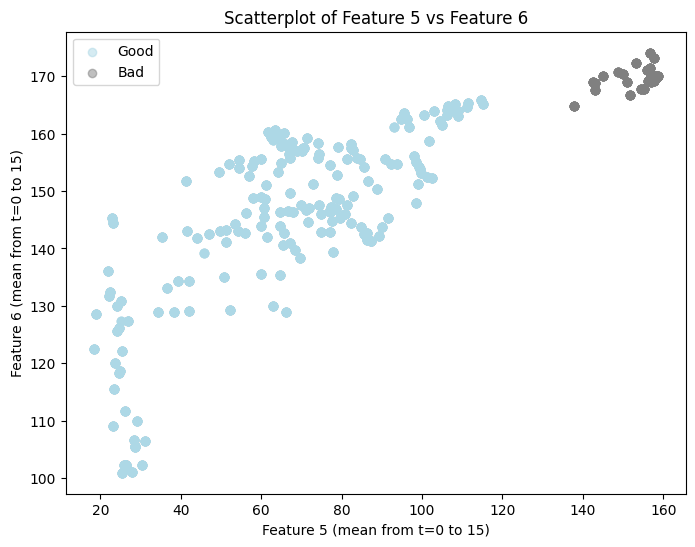

In [69]:
draw_scatterplot_features(0, 15, 5, 6)

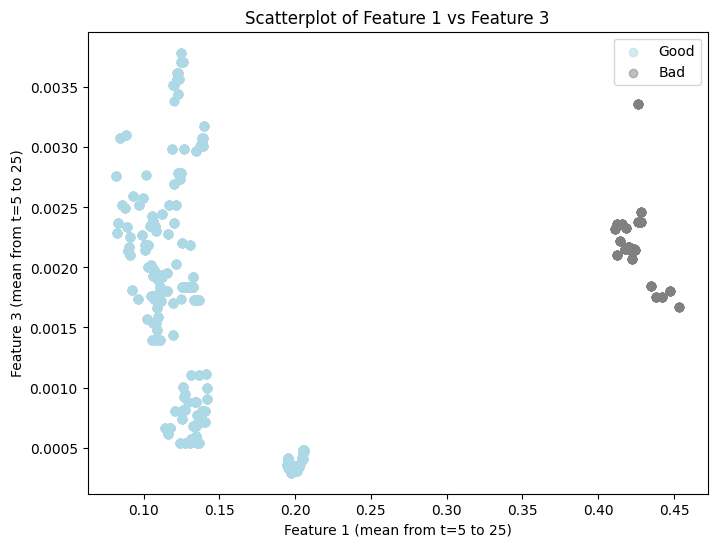

In [77]:
draw_scatterplot_features(5, 25, 1, 3)

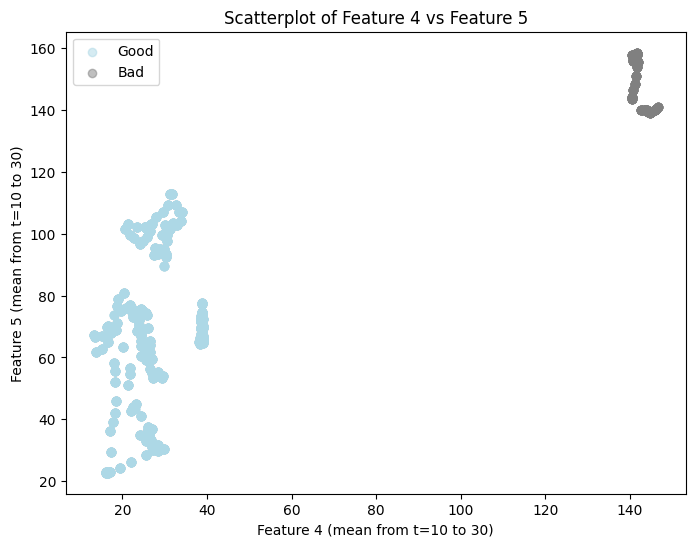

In [78]:
draw_scatterplot_features(10, 30, 4, 5)